In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import DataLoader, Subset
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib
from sklearn.base import clone


In [2]:
import torch

# 检查是否有可用的 GPU
if torch.cuda.is_available():
    print("CUDA 可用，GPU 可用。")
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"当前设备名称: {torch.cuda.get_device_name(0)}")
    print(f"当前设备总内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA 不可用，仅支持 CPU。")


CUDA 可用，GPU 可用。
CUDA 版本: 12.1
GPU 数量: 1
当前设备名称: NVIDIA GeForce RTX 3080 Ti
当前设备总内存: 11.76 GB


In [3]:
data=pd.read_excel("./algae.xlsx")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values

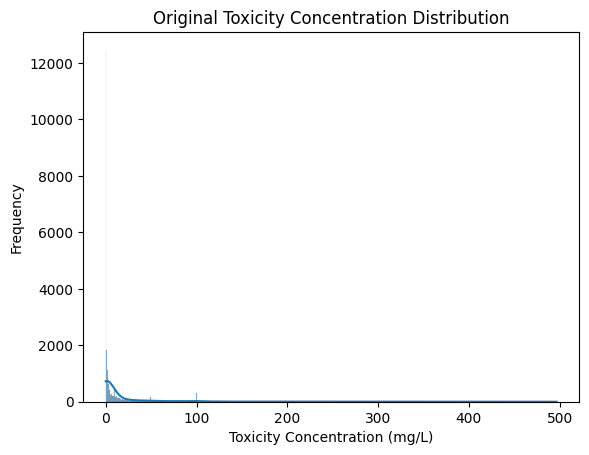

Mean: 21.71100774461388, Median: 0.94, Std Dev: 57.85672969022343


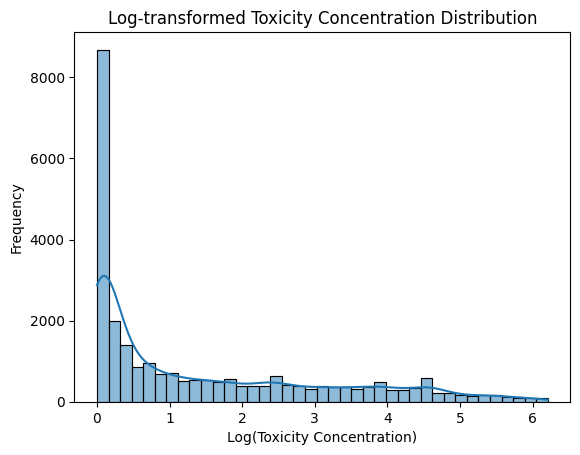

In [4]:

# 假设 mgperL 是毒性浓度数据的列表或数组
sns.histplot(mgperL, kde=True)
plt.title('Original Toxicity Concentration Distribution')
plt.xlabel('Toxicity Concentration (mg/L)')
plt.ylabel('Frequency')
plt.show()

# 统计信息
mean = np.mean(mgperL)
median = np.median(mgperL)
std_dev = np.std(mgperL)
print(f"Mean: {mean}, Median: {median}, Std Dev: {std_dev}")

# 应用 log1p 变换并再次查看分布
log_mgperL = np.log1p(mgperL)
sns.histplot(log_mgperL, kde=True)
plt.title('Log-transformed Toxicity Concentration Distribution')
plt.xlabel('Log(Toxicity Concentration)')
plt.ylabel('Frequency')
plt.show()

In [5]:
mgperL=np.log1p(mgperL)

In [6]:
# 数据增强函数：简单的 SMILES 序列翻转
def augment_smiles(smiles):
    """简单的数据增强方法，例如旋转 SMILES 字符串"""
    if random.random() > 0.5:
        return smiles[::-1]  # 翻转字符串
    return smiles


from torch.utils.data import Dataset
import torch

class SMILES_Dataset(Dataset):
    def __init__(self, smiles, reg_labels):
        self.smiles = smiles
        self.reg_labels = reg_labels  # 回归任务标签

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smiles = self.smiles[idx]  # 获取单个SMILES
        reg_label = self.reg_labels[idx]  # 获取回归标签
        tokens = tokenizer(smiles, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        return tokens, torch.tensor(reg_label, dtype=torch.float32)

# 多任务模型定义
class ChemBERTa_Regression(nn.Module):
    def __init__(self):
        super(ChemBERTa_Regression, self).__init__()
        # 加载预训练的ChemBERTa模型
        self.chemberta = chemberta_model  # 假设 chemberta_model 已定义
        hidden_size = self.chemberta.config.hidden_size  # 一般为768
        # 回归任务的全连接层
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        

    def forward(self, tokens):
        output = self.chemberta(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]  # [CLS] token 嵌入
        reg_output = self.regressor(cls_embedding)  # 回归任务输出
        return reg_output

In [7]:
# 加载 ChemBERTa 模型和 tokenizer
model_name = "../models/chemBERTa"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
chemberta_model = RobertaModel.from_pretrained(model_name)

/root/miniconda3/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [8]:
from torch.utils.data import DataLoader, random_split
# 加载数据集
dataset = SMILES_Dataset(smiles_data, mgperL)  # 传递 SMILES 数据和回归标签 mgperL

# 数据集划分：80% 训练集，20% 验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 数据加载器
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True)

In [9]:
# 判断是否使用GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 初始化回归任务模型
model = ChemBERTa_Regression().to(device)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm import tqdm

# 回归任务的损失函数
reg_criterion = nn.L1Loss()  # 使用 L1Loss 作为回归损失

# 优化器
optimizer = optim.Adam(model.parameters(), lr=2e-5)

# 训练模型
num_epochs = 100
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0

for epoch in range(num_epochs):
    model.train()
    running_reg_loss = 0.0
    
    # 使用 tqdm 包装 train_loader
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Training")
    for tokens, reg_labels in train_loader_tqdm:
        tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
        reg_labels = reg_labels.to(device)

        # 前向传播
        optimizer.zero_grad()
        reg_output = model(tokens)  # 只计算回归任务的输出

        # 计算回归任务的损失
        reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
        reg_loss.backward()
        optimizer.step()

        running_reg_loss += reg_loss.item()

        # 在 tqdm 显示回归损失
        train_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item()})

    avg_reg_loss = running_reg_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Reg Loss: {avg_reg_loss:.4f}")

    # 验证模型
    model.eval()
    val_reg_loss = 0.0
    all_preds = []
    all_labels = []
    
    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Validation")
    with torch.no_grad():
        for tokens, reg_labels in val_loader_tqdm:
            tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
            reg_labels = reg_labels.to(device)

            # 前向传播
            reg_output = model(tokens)

            # 计算回归任务的损失
            reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
            val_reg_loss += reg_loss.item()

            all_preds.extend(reg_output.squeeze().cpu().numpy())
            all_labels.extend(reg_labels.cpu().numpy())

            # 在 tqdm 显示回归损失
            val_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item()})

    avg_val_reg_loss = val_reg_loss / len(val_loader)
    val_mae = mean_absolute_error(all_labels, all_preds)  # 计算平均绝对误差 (MAE)
    val_r2 = r2_score(all_labels, all_preds)  # 计算 R²

    print(f"Val Reg Loss: {avg_val_reg_loss:.4f}, Val MAE: {val_mae:.4f}, Val R²: {val_r2:.4f}, Early Stop Counter: {early_stop_counter}")

    # 早停机制
    if avg_val_reg_loss < best_val_loss:
        best_val_loss = avg_val_reg_loss
        early_stop_counter = 0  # 重置早停计数器
        torch.save(model.state_dict(), 'best_regression_model.pth')  # 保存最好的模型
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"早停触发，在第 {epoch+1} 个 epoch 停止训练")
            break

Epoch [1/100] - Training: 100%|██████████| 652/652 [00:59<00:00, 10.92it/s, Reg Loss=1.44] 


Epoch [1/100], Train Reg Loss: 1.5246


Epoch [1/100] - Validation: 100%|██████████| 163/163 [00:05<00:00, 28.24it/s, Reg Loss=1.27] 


Val Reg Loss: 1.4406, Val MAE: 1.4406, Val R²: -0.5361, Early Stop Counter: 0


Epoch [2/100] - Training: 100%|██████████| 652/652 [00:59<00:00, 11.00it/s, Reg Loss=1.68] 


...

Val Reg Loss: 0.7352, Val MAE: 0.7352, Val R²: 0.4850, Early Stop Counter: 3


Epoch [41/100] - Training: 100%|██████████| 652/652 [01:03<00:00, 10.22it/s, Reg Loss=0.789]


Epoch [41/100], Train Reg Loss: 0.7160


Epoch [41/100] - Validation: 100%|██████████| 163/163 [00:06<00:00, 25.69it/s, Reg Loss=0.474]


Val Reg Loss: 0.7400, Val MAE: 0.7400, Val R²: 0.4769, Early Stop Counter: 4
早停触发，在第 41 个 epoch 停止训练


In [11]:
# 加载最佳模型
model.load_state_dict(torch.load('best_regression_model.pth'))

<All keys matched successfully>

In [12]:


# 提取 SMILES 的嵌入表示

# 提取 SMILES 的嵌入表示
def extract_embeddings(smiles_list, model, tokenizer, device):
    embeddings = []
    model.eval()  # 设置模型为评估模式
    with torch.no_grad():
        for smiles in smiles_list:
            # Tokenize the SMILES string
            tokens = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            
            # 通过 ChemBERTa 模型获得输出
            outputs = model.chemberta(**tokens)  # 提取 ChemBERTa 模型的输出
            
            # 提取 [CLS] token 的嵌入作为 SMILES 的整体嵌入
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # 获取多维的 [CLS] 嵌入
            embeddings.append(cls_embedding)
    
    return np.vstack(embeddings)  # 将所有嵌入拼接成一个矩阵

# 提取嵌入
smiles_embeddings = extract_embeddings(smiles_data, model, tokenizer, device)

In [13]:
from matplotlib import font_manager
# 指定字体路径
font_path = '../front/timesbd.ttf'
prop = font_manager.FontProperties(fname=font_path)

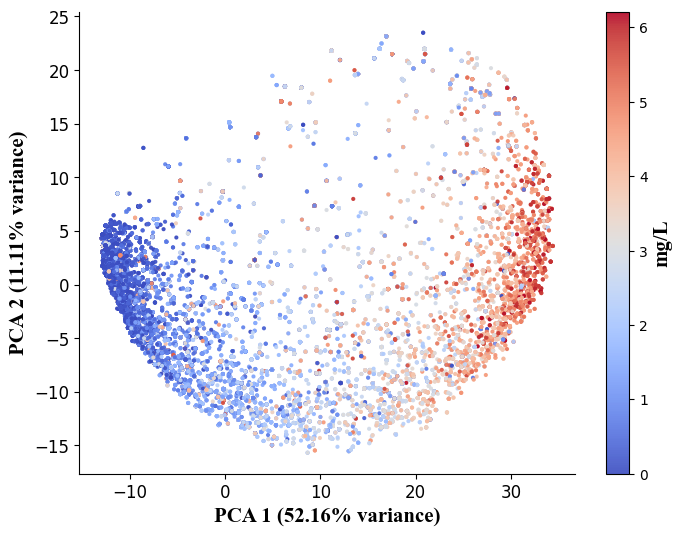

In [14]:
# 使用 PCA 对嵌入进行降维，同时获取主成分的解释方差百分比
def apply_pca(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(embeddings)
    explained_variance = pca.explained_variance_ratio_  # 获取每个主成分的解释方差
    return pca_result, explained_variance

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='coolwarm', alpha=0.9,s=4)
    # 添加 colorbar，不指定 fontsize 参数
    cbar = plt.colorbar(scatter)
    cbar.set_label('mg/L', fontsize=15,fontproperties=prop)  # 在此处设置字体大小
    plt.xlabel(f'PCA 1 ({explained_variance[0]*100:.2f}% variance)', fontsize=15,fontproperties=prop)
    plt.ylabel(f'PCA 2 ({explained_variance[1]*100:.2f}% variance)', fontsize=15,fontproperties=prop)

     # 获取当前坐标轴对象
    ax = plt.gca()

    # 设置所有边框的可见性，并确保框线颜色正常显示
    ax.spines['top'].set_visible(True)    # 显示顶部框线
    ax.spines['right'].set_visible(True)  # 显示右侧框线
    ax.spines['top'].set_color('black')   # 设置顶部框线颜色为黑色
    ax.spines['right'].set_color('black') # 设置右侧框线颜色为黑色
    ax.spines['top'].set_linewidth(1.5)   # 设置顶部框线的宽度
    ax.spines['right'].set_linewidth(1.5) # 设置右侧框线的宽度

    # 让其余边框可见（通常默认已可见）
    ax.spines['top'].set_visible(False)  # 显示左侧框线
    ax.spines['right'].set_visible(False)  # 显示底部框线
    
    ax.tick_params(axis='both', labelsize=12)  # 设置x轴和y轴刻度标签的字体大小为12

    
    plt.show()



# 使用 PCA 降维，并获取解释方差
pca_result, explained_variance = apply_pca(smiles_embeddings, n_components=2)

# 绘制 PCA 图，并显示每个主成分的解释方差百分比
plot_pca_with_variance(pca_result, mgperL, explained_variance)

In [15]:
np.save('./reg_smiles_embeddings.npy', smiles_embeddings)